In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats

Creating a random dataset

In [ ]:
np.random.seed(42)
n=500 #Number of rows in dataset

#Possible values for each column
categories  = ["Technology", "Furniture", "Office Supplies"]
regions     = ["West", "East", "Central", "South"]
segments    = ["Consumer", "Corporate", "Home Office"]

#Randomly pick values for each row
category_col = np.random.choice(categories, n)
region_col   = np.random.choice(regions, n)
segment_col  = np.random.choice(segments, n)

#Random sales no. between 50 to 3000 ("2" rounds the number to 2 decimal places)
sales_col = np.round(np.random.uniform(50, 3000, n), 2)

#Discount values (0%, 10%, 20%, 30%, or 50%)
discount_col = np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5], n)

#Profit column
profit_col   = np.round(sales_col * 0.25 * (1 - discount_col * 2), 2)

#Order dates between Jan 2021 and Dec 2023
start_date = pd.Timestamp("2021-01-01")
end_date   = pd.Timestamp("2023-12-31")
date_col   = pd.to_datetime(
    np.random.randint(start_date.value, end_date.value, n)
)

df = pd.DataFrame({
    "Order Date" : date_col,
    "Category"   : category_col,
    "Region"     : region_col,
    "Segment"    : segment_col,
    "Sales"      : sales_col,
    "Discount"   : discount_col,
    "Profit"     : profit_col,
})


Dataset

In [ ]:
print("Total Rows:" ,len(df))
print("Total Colums:" ,len(df.columns))
print("Column Names:" ,list(df.columns))
print("First 5 rows of data:")
print(df.head())
print(df.info())
df.dtypes

Statistical Analysis

In [ ]:
sales_list = df["Sales"]
#Basic Statistics
mean_sales = stats.mean(sales_list)
median_sales = stats.median(sales_list)
stdev_sales = stats.stdev(sales_list)
min_sales = min(sales_list)
max_sales = max(sales_list)

print("Mean:" ,mean_sales)
print("Median:" ,median_sales)
print("Standad Deviation:" ,stdev_sales)
print("Min Sales:" ,min_sales)
print("Max Sales:" ,max_sales)

Average Sales By Categories

In [ ]:
print("\nAverage Sales by Category:")
category_avg = df.groupby("Category")["Sales"].mean()
print(category_avg)

Total Profit By Region

In [ ]:
print("\nTotal Profit by Region:")
region_profit = df.groupby("Region")["Profit"].sum()
print(region_profit)

Correlation: Does discount affects profits

In [ ]:
correlation = df["Discount"].corr(df["Profit"])
print("\nCorrelation between Discount and Profit:", correlation)
if correlation < 0:
    print("  → Negative! Higher discounts = lower profits")
else:
    print("  → Positive! Higher discounts = higher profits")

Visualization

In [ ]:
#List of colours
colors = ["#ee6055", "#60d394", "#aaf683", "#ffd97d"]

In [ ]:
#Total Sales by Category (Bar Chart)
category_sales = df.groupby("Category")["Sales"].sum()
plt.bar(category_sales.index, category_sales.values, color=colors[:3], edgecolor="black")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")

In [ ]:
#Total Profit by Region (Bar Chart)
region_profit_chart = df.groupby("Region")["Profit"].sum()
bar_colors ="#48cae4"
plt.bar(region_profit_chart.index, region_profit_chart.values, color=bar_colors, edgecolor="black")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")

In [ ]:
#Sales Distribution (Histogram)
plt.hist(df["Sales"], bins=20, color="#2E86AB", edgecolor="white")
plt.axvline(mean_sales,   color="#E84855", linestyle="--", linewidth=1.5,
           label=f"Mean: ${mean_sales:.0f}")
plt.axvline(median_sales, color="#F4A261", linestyle="--", linewidth=1.5,
           label=f"Median: ${median_sales:.0f}")
plt.title("Sales Distribution")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")
plt.legend(fontsize=8)

In [ ]:
#Yearly Sales Trend (Line Chart)
df["Year"] = df["Order Date"].dt.year   # Extract year from the date column
yearly_sales = df.groupby("Year")["Sales"].sum()
plt.plot(yearly_sales.index, yearly_sales.values,
        marker="o", color="#2E86AB", linewidth=2, markersize=8)
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(yearly_sales.index)   # Only show years that exist in data

In [ ]:
#Discount vs Profit (Scatter Plot)
plt.scatter(df["Discount"], df["Profit"],
           alpha=0.4,       # alpha = transparency (so dots don't overlap)
           color="#9B5DE5",
           s=20)            # s = dot size
plt.title(f"Discount vs Profit  (r = {correlation:.2f})")
plt.xlabel("Discount Rate")
plt.ylabel("Profit ($)")
plt.axhline(y=0, color="red", linestyle="--", linewidth=0.8)  # Break-even line

In [ ]:
#Sales Share by Segment (Pie Chart)
segment_sales = df.groupby("Segment")["Sales"].sum()
plt.pie(segment_sales.values,
       labels=segment_sales.index,
       autopct="%1.1f%%",    # Show percentage on each slice
       colors=colors,
       startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Sales Share by Segment")

Key Findings

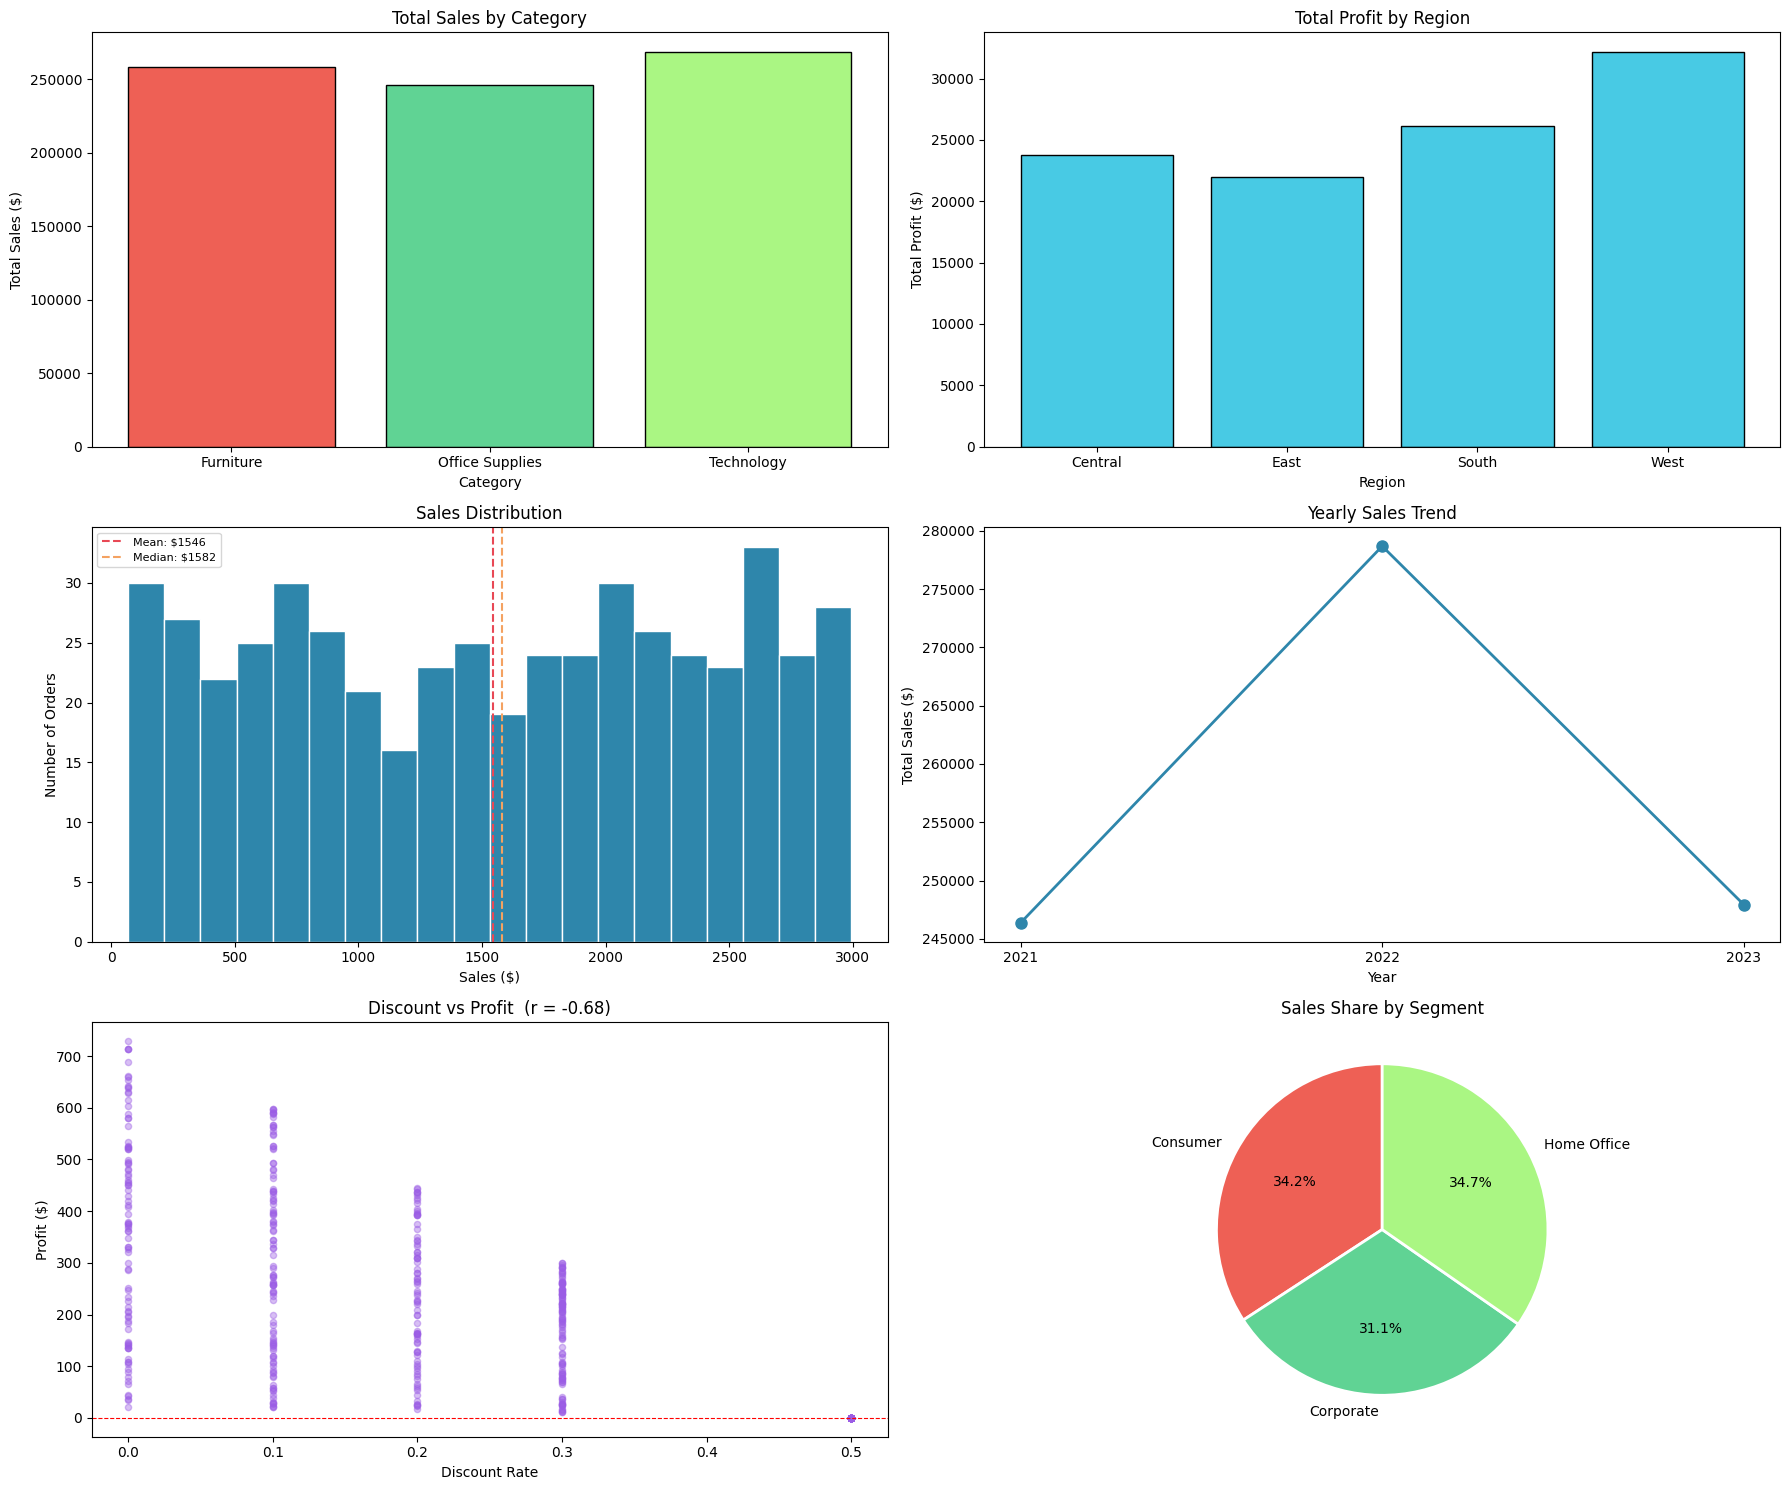

In [ ]:
best_category = category_sales.idxmax()
best_region   = region_profit_chart.idxmax()
worst_region  = region_profit_chart.idxmin()

print(f"""
  📊 Dataset size        : {len(df)} orders
  💰 Total Sales         : ${df['Sales'].sum():,.0f}
  📈 Total Profit        : ${df['Profit'].sum():,.0f}
  🏆 Best Category       : {best_category}  (highest sales)
  ✅ Best Region         : {best_region}   (highest profit)
  ⚠  Worst Region        : {worst_region}  (lowest profit)
  🔗 Discount-Profit link: {correlation:.2f}  (negative = discounts hurt profit)
""")